In [1]:
import pandas as pd
import re
import numpy as np
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr
import seaborn as sns
import matplotlib.pyplot as plt
import pyreadr
import matplotlib.cm as cm
from matplotlib.colors import to_hex

In [2]:
# Load correlation Data
uthh_epi = pd.read_csv("C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/90summaries/02uthealth_assoc_epiclocks-08052025.csv")
uthh_tra = pd.read_csv("C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/90summaries/02uthealth_assoc-08052025.csv")

In [3]:
# Bonferroni threshold
bonf_threshold = 0.05 / uthh_epi.shape[1]
print(bonf_threshold)
# Filter significant rows
significant_df = uthh_epi[uthh_epi['P-value'] < bonf_threshold]
significant_df

0.005555555555555556


,Phenotype,Clock,Beta,SE,z-value,P-value,CI_lower_95,CI_upper_95,Converged
65,Amphetamine,Zhang2019,4.407199,1.400671,3.146491,0.001652,1.661934,7.152463,True
74,Amphetamine,corticalClock_clock,6.994201,2.021716,3.459536,0.000541,3.031710,10.956692,True


In [4]:
# Define brain-related rows
brain_df = uthh_tra[uthh_tra['Tissue'].str.contains('brain', case=False, na=False)]
# Bonferroni correction based on number of tests in brain only
bonf_threshold = 0.05 / brain_df.shape[0]
print(bonf_threshold)
# Filter significant rows
significant_brain_df = brain_df[brain_df['P-value'] < bonf_threshold]
significant_brain_df

0.00045454545454545455


,Phenotype,Clock,Beta,SE,z-value,P-value,CI_lower_95,CI_upper_95,Converged,Tissue


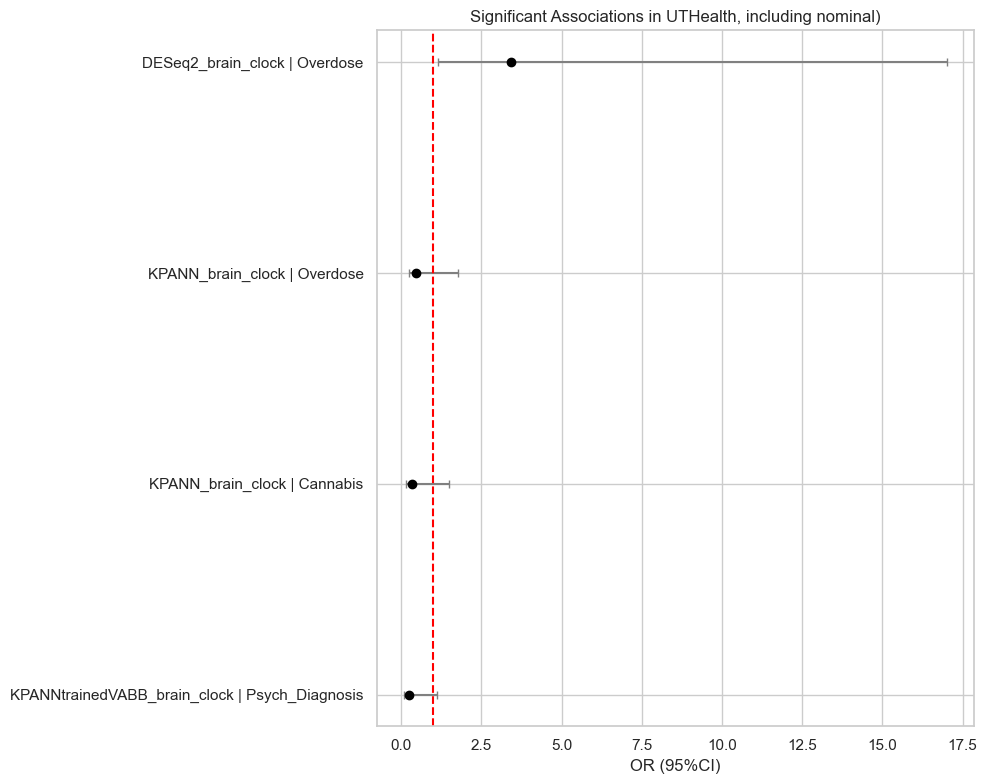

In [7]:
# Load your dataframe
df = brain_df.copy()

# Define brain-related tissues
brain_tissues = ['brain']

# Filter: significant results & brain tissues
brain_df = df[
    (df['P-value'] < 0.05) &
    (df['Tissue'].str.lower().isin(brain_tissues))
].copy()

# Add OR and 95% CI for OR
brain_df['OR'] = np.exp(brain_df['Beta'])
brain_df['OR_lower'] = np.exp(brain_df['CI_lower_95'])
brain_df['OR_upper'] = np.exp(brain_df['CI_upper_95'])

# Sort by beta for visual clarity
brain_df = brain_df.sort_values('Beta')

# Plot
plt.figure(figsize=(10, 8))
sns.set(style="whitegrid")

# Error bars = 95% CI
plt.errorbar(
    x=brain_df['OR'],
    y=brain_df['Clock'] + ' | ' + brain_df['Phenotype'],
    xerr=[brain_df['OR'] - brain_df['OR_lower'],
          brain_df['OR'] + brain_df['OR_upper']],
    fmt='o',
    color='black',
    ecolor='gray',
    capsize=3
)

plt.axvline(1.0, color='red', linestyle='--')
plt.xlabel('OR (95%CI)')
plt.title('Significant Associations in UTHealth, including nominal)')
plt.tight_layout()
plt.show()

In [ ]:
# Load your dataframe
df = uthh_epi.copy()

# Define brain-related tissues
brain_tissues = ['brain']

# Filter: significant results & brain tissues
brain_df = df[
    (df['P-value'] < 0.05)
].copy()

# Add OR and 95% CI for OR
brain_df['OR'] = np.exp(brain_df['Beta'])
brain_df['OR_lower'] = np.exp(brain_df['CI_lower_95'])
brain_df['OR_upper'] = np.exp(brain_df['CI_upper_95'])

# Sort by beta for visual clarity
brain_df = brain_df.sort_values('Beta')

# Plot
plt.figure(figsize=(10, 8))
sns.set(style="whitegrid")

# Error bars = 95% CI
plt.errorbar(
    x=brain_df['OR'],
    y=brain_df['Clock'] + ' | ' + brain_df['Phenotype'],
    xerr=[brain_df['OR'] - brain_df['OR_lower'],
          brain_df['OR'] + brain_df['OR_upper']],
    fmt='o',
    color='black',
    ecolor='gray',
    capsize=3
)

plt.axvline(1.0, color='red', linestyle='--')
plt.xlabel('OR (95%CI)')
plt.title('Significant Associations in UTHealth, including nominal)')
plt.tight_layout()
plt.show()

In [ ]:
# Copy DataFrame
df = uthh_epi.copy()

# Filter significant rows
brain_df = df[df['P-value'] < 0.05].copy()

# Compute OR and CIs
brain_df['OR'] = np.exp(brain_df['Beta'])
brain_df['OR_lower'] = np.exp(brain_df['CI_lower_95'])
brain_df['OR_upper'] = np.exp(brain_df['CI_upper_95'])

# Sort by Beta and remove last four row
brain_df = brain_df.sort_values('Beta').iloc[:-4].copy()

# Rebuild y-axis labels
brain_df['Label'] = brain_df['Clock'] + ' | ' + brain_df['Phenotype']

# Plot
plt.figure(figsize=(10, 8))
sns.set(style="whitegrid")

plt.errorbar(
    x=brain_df['OR'],
    y=brain_df['Label'],
    xerr=[
        brain_df['OR'] - brain_df['OR_lower'],
        brain_df['OR_upper'] - brain_df['OR']
    ],
    fmt='o',
    color='black',
    ecolor='gray',
    capsize=3
)

plt.axvline(1.0, color='red', linestyle='--')
plt.xlabel('OR (95% CI)')
plt.title('Significant Associations in UTHealth (nominal)')
plt.tight_layout()
plt.show()